In [5]:
import os
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import matplotlib.pyplot as plt

In [6]:
path = './Animal-Sound-Dataset'

rows = []
for folder_name in os.listdir(path):
    folder_path = os.path.join(path, folder_name)
    if not os.path.isdir(folder_path):
        continue
    for file in os.listdir(folder_path):
        if file.lower().endswith('.wav'):
            path = os.path.join(folder_path, file)
            try:
                info = sf.info(path)
                rows.append({
                    'label':       folder_name.lower(),
                    'file_path':   path,
                    'duration_s':  info.duration,
                    'sample_rate': info.samplerate,
                })
            except Exception:
                pass

df = pd.DataFrame(rows)
print(df['label'].value_counts())
print(df[['duration_s', 'sample_rate']].describe().round(2))

label
aslan    45
Name: count, dtype: int64
       duration_s  sample_rate
count       45.00        45.00
mean         4.38     14259.02
std          3.29      6529.94
min          0.91      8000.00
25%          1.67     11025.00
50%          3.51     11025.00
75%          5.96     16000.00
max         13.86     44100.00


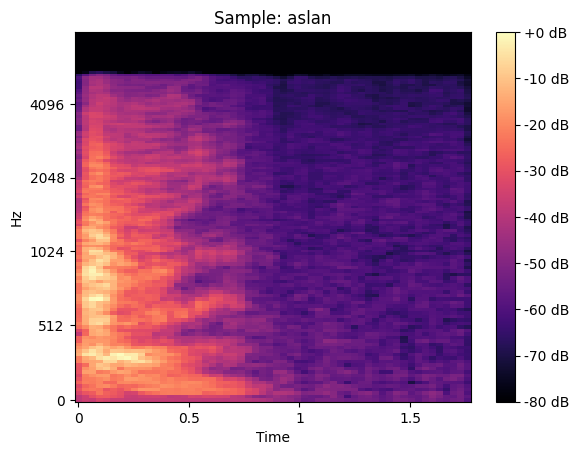

In [7]:
sample = df.sample(1, random_state=42).iloc[0]
y, sr = librosa.load(sample['file_path'], sr=16000, mono=True)

S_db = librosa.power_to_db(librosa.feature.melspectrogram(y=y, sr=sr), ref=np.max)
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel')
plt.title(f"Sample: {sample['label']}")
plt.colorbar(format='%+2.0f dB')
plt.show()